1.	Analyse globale du DataSet

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
#Chargement des données 
Data = pd.read_csv('Airbnb prediction.csv', delimiter=',')

In [2]:
#Nettoyage initial 
Data.drop(columns=['id','description', 'first_review', 'host_has_profile_pic', 
                   'host_identity_verified',  'host_response_rate', 'host_since', 
                   'last_review', 'latitude', 'longitude', 'name','number_of_reviews',
                   'review_scores_rating', 'thumbnail_url', 'zipcode'], inplace=True)
#Exploration du jeu de données 
print(f"Taille du dataSet : {Data.shape}")
Data.dtypes.value_counts()

Taille du dataSet : (74111, 14)


object     8
float64    4
int64      1
bool       1
Name: count, dtype: int64

In [3]:
#Gestion des doublons
print(f"Nombre de doubloms : {Data[Data.duplicated()==True].shape[0]}")
Data.drop_duplicates(inplace=True)

Nombre de doubloms : 269


In [4]:
#Analyse des valeurs manquantes 
df=pd.DataFrame(Data.isna().sum(), columns=['total'])
df[df['total']>0].sort_values(['total'], ascending=False)

,total
neighbourhood,6826
bathrooms,199
beds,131
bedrooms,90


2.	Analyse de la target

<Axes: xlabel='log_price', ylabel='Count'>

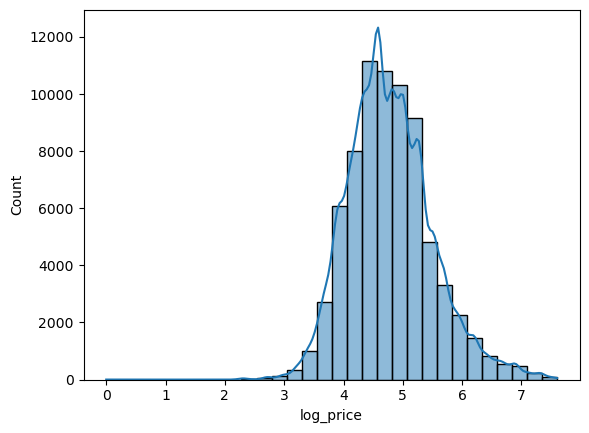

In [5]:
#Distribution des prix 
sns.histplot(data=Data, x='log_price', bins=30, kde=True)

<Axes: xlabel='price', ylabel='Count'>

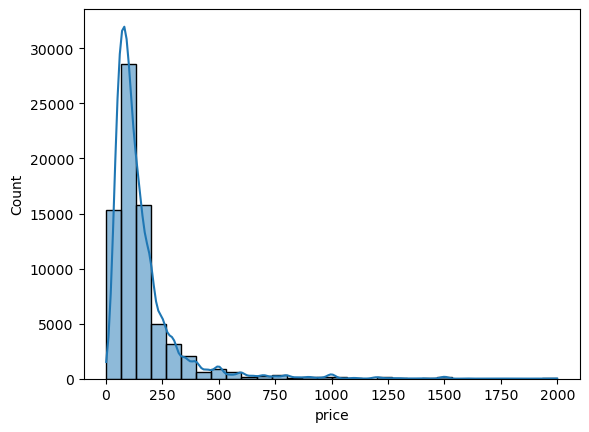

In [6]:
#Comparaison avec les prix réels 
Data['price']=Data['log_price'].apply(lambda x : math.exp(x))
sns.histplot(data=Data, x='price', bins=30, kde=True)

In [7]:
#Transformation de la target 
Data.drop(columns=['log_price'], inplace=True)

In [8]:
#Nettoyage des valeurs extrêmes 
Data=Data[Data.price>10]
print(f"Nombre de locations supérieures à 1000$ : {Data[Data['price']>1000].shape[0]}")

Nombre de locations supérieures à 1000$ : 668


In [9]:
#Comparaison des moyennes > 1000$
Data[(Data['price']>1000)].select_dtypes(exclude=['object']).mean()

accommodates       7.287425
bathrooms          2.723388
cleaning_fee       0.550898
bedrooms           2.950599
beds               3.642216
price           1289.420659
dtype: float64

In [10]:
#Comparaison des moyennes < 200$
Data[(Data['price']<200)].select_dtypes(exclude=['object']).mean()

accommodates      2.645815
bathrooms         1.126584
cleaning_fee      0.722966
bedrooms          1.068956
beds              1.454146
price           103.493204
dtype: float64

3.	Analyse du type de propriété

In [11]:
#Exploration du type de propriété
print(f"Nombre de type de propriétés : {len(Data.property_type.unique())}")

Nombre de type de propriétés : 35


In [12]:
#Analyse descriptive 
df=Data.groupby('property_type')['price'].agg(count='count',mean='mean').sort_values(by='count')
df

,count,mean
property_type,,
Casa particular,1,80.000000
Parking Space,1,100.000000
Island,1,150.000000
Lighthouse,1,250.000000
Train,2,182.500000
Cave,2,136.000000
Tipi,3,232.333333
Earth House,4,356.250000
Chalet,6,127.833333


In [13]:
#Réduction du nombre de catégories 
Lmoins50=list(df[df['count']<50].index)
Lplus50=list(df[df['count']>50].index)

In [14]:
#Regroupement des types rares (approche NLP) :
import spacy	 
!python -m spacy download en_core_web_md > /dev/null 2>&1
nlp = spacy.load("en_core_web_md")	

In [15]:
#Calcul de la similarité des types rares :
similarities = {}
for target in Lmoins50 :
    sim = [(w, nlp(target).similarity(nlp(w))) for w in Lplus50]
    similarities[target]=sorted(sim, key=lambda x: x[1], reverse=True)[0]

In [16]:
for k, v in similarities.items():
    print(f"{k:<20} : {v[0]:<20}  {v[1]:.4f}")

Casa particular      : Villa                 0.2774
Parking Space        : Bungalow              0.6063
Island               : Camper/RV             0.5516
Lighthouse           : Camper/RV             0.5538
Train                : Bungalow              0.3961
Cave                 : Other                 0.3170
Tipi                 : Villa                 0.1505
Earth House          : House                 0.7629
Chalet               : Boutique hotel        0.2368
Treehouse            : Camper/RV             0.3941
Hut                  : Boat                  0.3326
Yurt                 : Villa                 0.1543
Vacation home        : Townhouse             0.5971
Castle               : Other                 0.3170
Tent                 : Boat                  0.3326
Serviced apartment   : Townhouse             0.7900


In [17]:
#Transformation des types rares 
Data.property_type=Data.property_type.apply( lambda x: similarities[x][0] 
    if (x in similarities and similarities[x][1] > 0.5) else x)
Data.property_type.value_counts()

property_type
Apartment          48846
House              16444
Condominium         2651
Townhouse           1720
Loft                1242
Other                605
Guesthouse           497
Bed & Breakfast      454
Bungalow             367
Villa                177
Dorm                 135
Guest suite          122
Camper/RV             96
Timeshare             77
Cabin                 72
In-law                71
Boutique hotel        68
Boat                  64
Hostel                63
Tent                  18
Castle                13
Yurt                   9
Hut                    8
Treehouse              7
Chalet                 6
Tipi                   3
Train                  2
Cave                   2
Casa particular        1
Name: count, dtype: int64

In [18]:
Data=Data[Data['property_type'].isin(Lplus50)] 

In [19]:
#Détection des outliers 
outliers={}
for type_pro in Data.property_type.unique():
    Q3=Data[Data.property_type==type_pro]['price'].quantile(0.75)
    Q1=Data[Data.property_type==type_pro]['price'].quantile(0.25)
    outliers[type_pro]=(Q3+3*(Q3-Q1), Data[Data.property_type==type_pro]['price'].mean())
for v in sorted(outliers.items(), key=lambda x: x[1][0]):
    print(f'{v[0]:<20} {v[1][0]:<20.2f} {v[1][1]:.2f}')

Dorm                 133.00               51.71
Hostel               283.00               59.81
Guesthouse           320.00               125.43
In-law               322.50               135.93
Bungalow             330.00               135.29
Bed & Breakfast      332.00               117.08
Guest suite          358.25               128.66
Cabin                375.00               118.12
Camper/RV            418.75               134.03
Boutique hotel       469.00               223.28
Apartment            475.00               146.34
Townhouse            590.00               183.47
Other                643.00               212.73
House                650.00               188.86
Loft                 668.00               204.12
Condominium          730.00               204.90
Boat                 755.00               252.61
Timeshare            996.00               310.45
Villa                1423.00              385.77


In [20]:
#Nombre d'outliers par type de propriétés
pd.DataFrame((Data.groupby('property_type')['price'].apply(lambda x: (x > outliers[x.name][0])
    .sum()))).sort_values(by='price')

,price
property_type,
Cabin,0
In-law,0
Timeshare,0
Hostel,1
Guest suite,3
Camper/RV,3
Boutique hotel,4
Dorm,5
Boat,5


4.	Analyse des types de chambre

In [21]:
#Analyse des types de chambre 
df=Data.groupby('room_type')['price'].agg(count='count',mean='mean').sort_values(by='count')
df

,count,mean
room_type,,
Shared room,2111,64.492184
Private room,30487,88.483583
Entire home/apt,41173,218.763121


<Axes: xlabel='room_type', ylabel='price'>

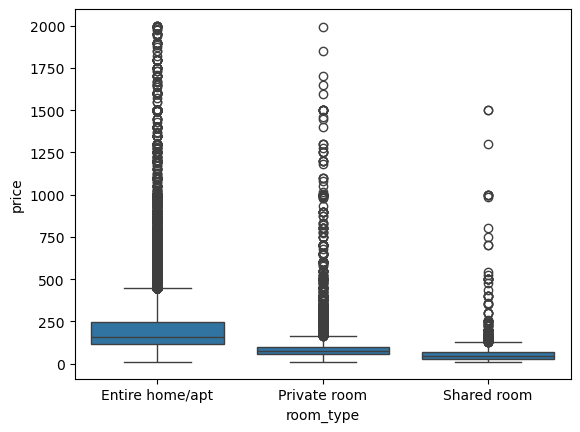

In [22]:
#Visualisation des distributions de prix 
sns.boxplot(data=Data, x='room_type', y='price')

<Axes: xlabel='price', ylabel='Count'>

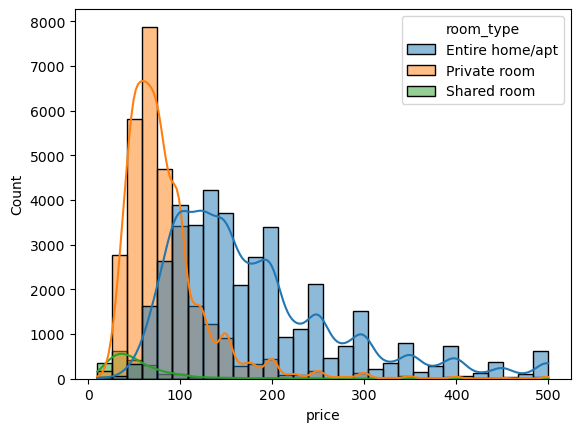

In [23]:
#Analyse de la variation des prix 
Dt=Data[Data['price']<500]
sns.histplot(data=Dt, x='price', kde=True, hue='room_type', bins=30)

5.	Analyse de la feature accomodates

In [24]:
#Exploration des valeurs possibles 
df=Data.groupby('accommodates')['price'].agg(count='count',mean='mean').sort_values(by='mean')
df

,count,mean
accommodates,,
1,9388,80.487963
2,31711,112.193876
3,7753,143.471430
4,12024,190.243513
5,3422,233.791058
6,4953,292.012518
7,941,312.937301
9,268,360.977612
13,36,392.611111


In [25]:
#Préparation des données  
sc = MinMaxScaler()
Data.accommodates=sc.fit_transform(Data[['accommodates']])

6.	Analyse de la feature bathrooms

In [26]:
#Influence entre le nombre de salles de bains et le prix 
df=Data.groupby('bathrooms')['price'].agg(count='count',mean='mean').sort_values(by='mean')
df

,count,mean
bathrooms,,
0.5,207,92.628019
0.0,192,100.359375
1.0,57874,131.117341
1.5,3791,165.176207
2.0,7878,247.511043
2.5,1561,357.121076
3.0,1049,385.215443
8.0,38,445.763158
4.0,276,518.713768


In [27]:
#Analyse croisée avec le type de chambre 
Dt=Data[Data.bathrooms==8.0]
Dt.groupby(['room_type'])['price'].mean()

room_type
Entire home/apt    1558.000000
Private room         88.800000
Shared room          39.782609
Name: price, dtype: float64

In [28]:
#Traitement des valeurs manquantes 
prixMoyen=Data[Data.bathrooms.isna()]['price'].mean()
print(f'Prix moyen des valeurs manquantes : {prixMoyen}')
Data.bathrooms=Data.bathrooms.fillna(value=1)

Prix moyen des valeurs manquantes : 130.4924623115578


In [29]:
#Normalisation 
Data.bathrooms=sc.fit_transform(Data[['bathrooms']])

7.	Analyse de la feature bed_type

In [30]:
#Analyse des types de lit 
df=Data.groupby('bed_type')['price'].agg(count='count',mean='mean').sort_values(by='mean')
df

,count,mean
bed_type,,
Futon,751,92.918775
Pull-out Sofa,584,102.722603
Airbed,471,109.263270
Couch,268,111.100746
Real Bed,71697,162.208544


In [31]:
#Regroupement en deux catégories 
Data.bed_type=Data.bed_type.apply(lambda x : 1 if x=='Real Bed' else 0) 	 

8.	Analyse de la cancelation_policy

In [32]:
#Analyse des politiques d'annulation 
df=Data.groupby('cancellation_policy')['price'].agg(count='count',mean='mean').sort_values(by='mean')
df

,count,mean
cancellation_policy,,
moderate,18996,141.554380
flexible,22471,150.435539
strict,32175,177.966900
super_strict_30,112,264.205357
super_strict_60,17,929.176471


In [33]:
#Transformation des données 
Cancelation=list(df.index)
Data.cancellation_policy=Data.cancellation_policy.apply(lambda x : Cancelation.index(x))
Data.cancellation_policy.value_counts()

cancellation_policy
2    32175
1    22471
0    18996
3      112
4       17
Name: count, dtype: int64

In [34]:
#Normalisation 
Data.cancellation_policy=sc.fit_transform(Data[['cancellation_policy']])

9.	Analyse des features cleaning_fee et instant_bookable

<Axes: xlabel='price', ylabel='Count'>

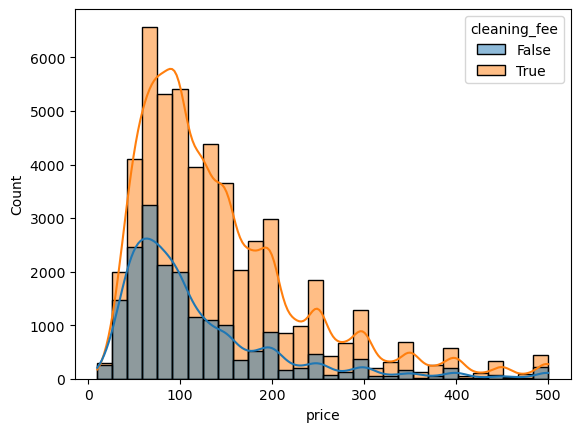

In [35]:
#Exploration de cleaning_fee 
Dt=Data[Data['price']<500]
sns.histplot(data=Dt, x='price', kde=True, bins=30, hue='cleaning_fee') 

In [36]:
#Suppression de la feature 
Data.drop(columns=['cleaning_fee'], inplace=True)

<Axes: xlabel='price', ylabel='Count'>

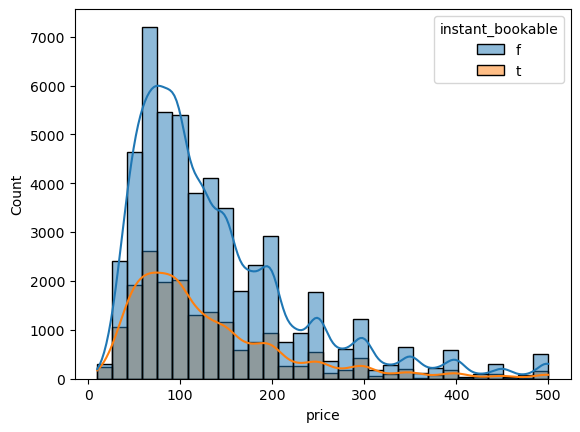

In [37]:
#Exploration de instant_bookable 
Dt=Data[Data['price']<500]
sns.histplot(data=Dt, x='price', kde=True, bins=30, hue='instant_bookable') 

In [38]:
#Suppression de la feature 
Data.drop(columns=['instant_bookable'], inplace=True)

10.	Analyse de la variable bedrooms

In [39]:
#Prix moyen par nombre de lits  
df=Data.groupby('bedrooms')['price'].agg(count='count',mean='mean').sort_values(by='mean')
df

,count,mean
bedrooms,,
1.0,49535,114.926012
0.0,6684,143.992968
2.0,11308,233.518217
3.0,4298,349.833644
4.0,1326,498.949472
5.0,355,629.200000
6.0,105,805.857143
9.0,8,807.375000
10.0,10,824.000000


In [40]:
#Analyse des valeurs manquantes 
prixMoyen=Data[Data.bedrooms.isna()]['price'].mean()
print(f'Nombre de valeurs manquantes : {Data[Data.bedrooms.isna()==True].shape[0]} - prix moyen {prixMoyen:.4f}')

Nombre de valeurs manquantes : 90 - prix moyen 133.7556


In [41]:
#Traitement des valeurs aberrantes 
Data.bedrooms=Data.bedrooms.apply(lambda x : 1 if x==0 else x)
Data[Data.bedrooms.isna()]['property_type'].value_counts()

property_type
Apartment      73
House           9
Loft            3
Other           2
Villa           1
Bungalow        1
Condominium     1
Name: count, dtype: int64

In [42]:
#Imputation des valeurs manquantes 
Data.bedrooms=Data.bedrooms.fillna(value=1)
#Normalisation 
Data.bedrooms=sc.fit_transform(Data[['bedrooms']])

11.	Analyse de la variable beds

In [43]:
#Analyse des valeurs manquantes 
prixMoyen=Data[Data.beds.isna()]['price'].mean()
print(f'Nombre de valeurs manquantes : {Data[Data.beds.isna()==True].shape[0]} - prix moyen {prixMoyen:.4f}')

Nombre de valeurs manquantes : 131 - prix moyen 124.7481


In [44]:
#Prix moyen par nombre de lits 
df=Data.groupby('beds')['price'].agg(count='count',mean='mean').sort_values(by='mean')
df

,count,mean
beds,,
1.0,44933,112.720985
2.0,16632,182.980640
0.0,4,250.750000
3.0,6423,258.285069
4.0,3050,320.470492
8.0,180,371.861111
5.0,1283,393.697584
6.0,656,413.400915
7.0,214,459.387850


In [45]:
#Imputation des valeurs manquantes 
Data.beds=Data.beds.fillna(value=1)
#Normalisation 
Data.beds=sc.fit_transform(Data[['beds']])

12.	Analyse de la variable city

In [46]:
#Répartition par ville 
df=Data.groupby('city')['price'].agg(count='count',mean='mean').sort_values(by='mean')
df

,count,mean
city,,
Chicago,3703,132.644883
NYC,32269,143.157891
LA,22299,155.705816
Boston,3421,164.635194
DC,5667,218.049409
SF,6412,227.564410


<Axes: xlabel='price', ylabel='Count'>

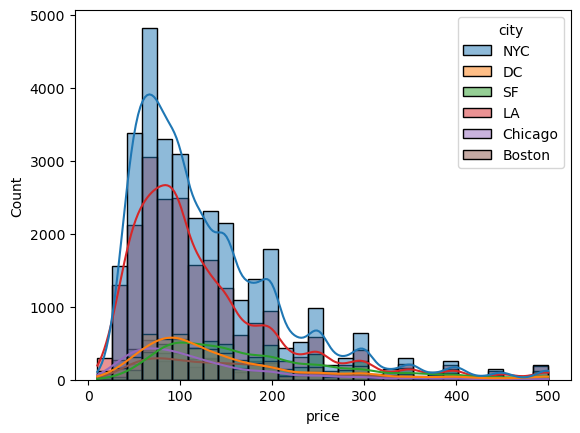

In [47]:
#Analyse détaillée 
df=Data[Data['price']<500]
sns.histplot(data=df, x='price', kde=True, bins=30, hue='city') 

13.	Influence des features

In [48]:
DataCopie = Data.copy()
#Transformation des données : Type de propriété
Data = pd.get_dummies(data=Data, columns= ['property_type'], drop_first=True, prefix_sep='',prefix='')
#Transformation des données : Type de chambre
Data = pd.get_dummies(data=Data, columns= ['room_type'], prefix_sep='',prefix='')
Data.drop(columns=['Shared room'], inplace=True)
#Transformation des données : City
Data = pd.get_dummies(data=Data, columns= ['city'], drop_first=True, prefix_sep='',prefix='')
Data.columns

Index(['amenities', 'accommodates', 'bathrooms', 'bed_type',
       'cancellation_policy', 'neighbourhood', 'bedrooms', 'beds', 'price',
       'Bed & Breakfast', 'Boat', 'Boutique hotel', 'Bungalow', 'Cabin',
       'Camper/RV', 'Condominium', 'Dorm', 'Guest suite', 'Guesthouse',
       'Hostel', 'House', 'In-law', 'Loft', 'Other', 'Timeshare', 'Townhouse',
       'Villa', 'Entire home/apt', 'Private room', 'Chicago', 'DC', 'LA',
       'NYC', 'SF'],
      dtype='object')

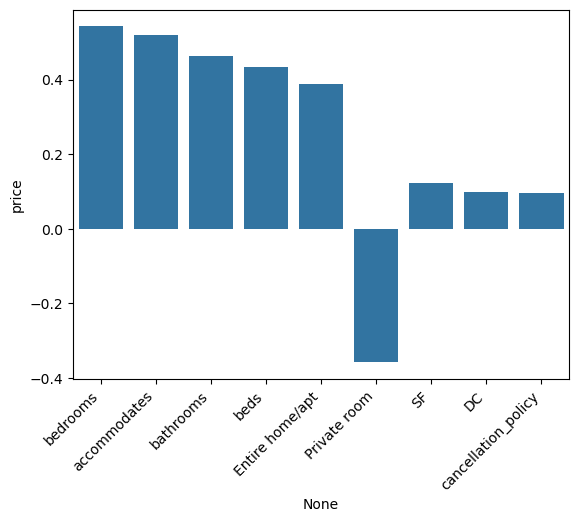

In [49]:
#Calcul des corrélations 
df=pd.DataFrame(Data.drop(['amenities','neighbourhood'], axis=1).corr()['price'])
df=df.sort_values(by='price', key=abs, ascending=False)[1:10]
sns.barplot(data=df, x=df.index, y='price')
plt.xticks(rotation=45, ha='right') 
plt.show()

14.	Traitement des quartiers

In [50]:
#Identification des quartiers 
print(f'Nombre de quartiers différents : {len(Data.neighbourhood.unique())}')

Nombre de quartiers différents : 620


<Axes: xlabel='price', ylabel='Count'>

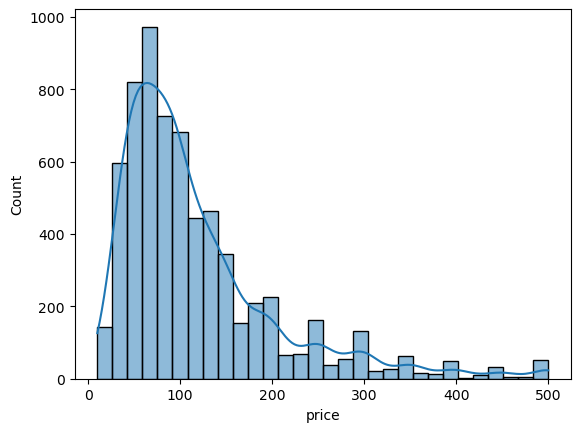

In [51]:
#Étude des valeurs manquantes 
df=Data[(Data.neighbourhood.isna()==True) & (Data['price']<500)]
sns.histplot(data=df, x='price', bins=30, kde=True)

<Axes: xlabel='price', ylabel='Count'>

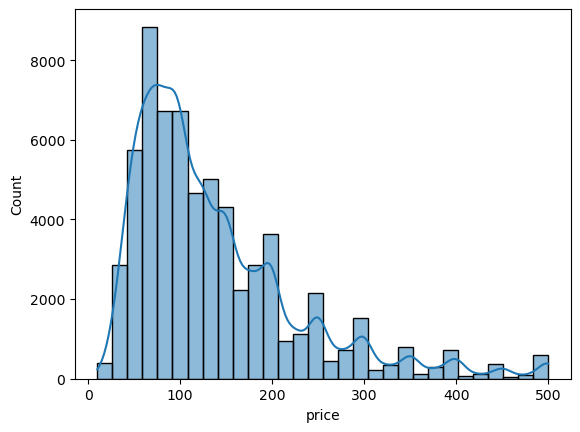

In [52]:
#Variantion prix moyens 
df=Data[(Data.neighbourhood.isna()!=True) & (Data['price']<500)]
sns.histplot(data=df, x='price', bins=30, kde=True)

In [53]:
#Nettoyage des données 
Data.dropna(subset=['neighbourhood'],axis=0, inplace=True)

In [54]:
#Regroupement des quartiers par tranches de prix 
df=Data.groupby('neighbourhood')['price'].agg(count='count',mean='mean').sort_values(by='mean')
#Découpage en bacs
df['Categorie'] = pd.cut(df['mean'], bins=50, labels=False)
df['Categorie'].value_counts()

Categorie
2     116
3      98
1      84
4      67
5      48
6      46
7      43
8      30
0      24
9      14
10     12
11      9
13      8
12      7
19      2
17      2
25      2
14      1
15      1
18      1
30      1
31      1
48      1
49      1
Name: count, dtype: int64

In [55]:
#Regroupement de bacs 
df['Categorie']=df['Categorie'].apply(lambda x : x if x<10 else 10)
df['Categorie'].value_counts()

Categorie
2     116
3      98
1      84
4      67
10     49
5      48
6      46
7      43
8      30
0      24
9      14
Name: count, dtype: int64

In [56]:
df

,count,mean,Categorie
neighbourhood,,,
South Chicago,6,25.000000,0
West Elsdon,3,30.000000,0
West Lawn,4,36.250000,0
"Suitland-Silver Hill, MD",1,37.000000,0
Edison Park,1,40.000000,0
...,...,...,...
Bellevue,3,671.666667,10
Sea Cliff,5,797.000000,10
Observatory Circle,1,825.000000,10


In [57]:
#Transformation et normalisation 
Data['neighbourhood']=Data.neighbourhood.map(df['Categorie'])
#Normalisation 
Data.neighbourhood=sc.fit_transform(Data[['neighbourhood']])

In [58]:
Data.iloc[0]['amenities']

'{"Wireless Internet","Air conditioning",Kitchen,Heating,"Family/kid friendly",Essentials,"Hair dryer",Iron,"translation missing: en.hosting_amenity_50"}'

In [59]:
import re

In [60]:
Data.amenities = Data.amenities.apply(lambda x : re.sub(r'[\{\}\"]','',x))

In [61]:
set(amenity.strip()
    for row in Data.amenities.dropna()
    for amenity in row.split(','))



{'',
 '24-hour check-in',
 'Accessible-height bed',
 'Accessible-height toilet',
 'Air conditioning',
 'Air purifier',
 'BBQ grill',
 'Baby bath',
 'Baby monitor',
 'Babysitter recommendations',
 'Bath towel',
 'Bathtub',
 'Bathtub with shower chair',
 'Beach essentials',
 'Beachfront',
 'Bed linens',
 'Body soap',
 'Breakfast',
 'Buzzer/wireless intercom',
 'Cable TV',
 'Carbon monoxide detector',
 'Cat(s)',
 'Changing table',
 'Children’s books and toys',
 'Children’s dinnerware',
 'Cleaning before checkout',
 'Coffee maker',
 'Cooking basics',
 'Crib',
 'Disabled parking spot',
 'Dishes and silverware',
 'Dishwasher',
 'Dog(s)',
 'Doorman',
 'Doorman Entry',
 'Dryer',
 'EV charger',
 'Elevator',
 'Elevator in building',
 'Essentials',
 'Ethernet connection',
 'Extra pillows and blankets',
 'Family/kid friendly',
 'Fire extinguisher',
 'Fireplace guards',
 'Firm matress',
 'Firm mattress',
 'First aid kit',
 'Fixed grab bars for shower & toilet',
 'Flat',
 'Flat smooth pathway to fro

In [62]:
to_replace_ = list(["Doorman Entry", "Elevator in building" , "Internet" , "Firm matress", "Other pet(s)", "Smart lock", "Wide clearance to bed", "Wide clearance to shower & toilet", "Wide clearance to shower and toilet", "translation missing: en.hosting_amenity_49", "translation missing: en.hosting_amenity_50", "Waterfront", "Other"])
replace_ = list(["Doorman", "Elevator", "Ethernet connection" ,"Firm mattress", "Pets allowed",  "Smartlock" , "Wide clearance", "Wide clearance", "Wide clearance", "translation missing", "translation missing", "Beachfront", "Others"])

In [63]:
Data.amenities = Data.amenities.replace(to_replace=to_replace_, value=replace_, regex=True)

In [64]:
def encodage(df):
    amenities=set(amenity.strip()
        for row in df.amenities.dropna()
                  for amenity in row.split(','))
    for amenitie in amenities :
        print(amenitie)
        dummies = pd.DataFrame([1 if amenitie in s.split(',') else 0 for s in df['amenities']],
            index=Data.index, columns=[amenitie])
        df = pd.concat([df, dummies], axis=1)
    df.drop(['amenities'], axis=1, inplace=True)
    return df, amenities

In [65]:
Df, amenities = encodage(Data)


Smoke detector
Accessible-height toilet
High chair
Wide entryway
Luggage dropoff allowed
Pets allowed
Step-free access
TV
Garden or backyard
Washer / Dryer
Cleaning before checkout
Bed linens
Beach essentials
Path to entrance lit at night
Coffee maker
Air purifier
Wide clearance
First aid kit
Firm mattress
Self Check-In
Wide doorway
Others
Pack ’n Play/travel crib
Pocket wifi
Hand or paper towel
Changing table
Accessible-height bed
Suitable for events
Dryer
Host greets you
Laptop friendly workspace
Fixed grab bars for shower & toilet
Washer
Children’s books and toys
Private bathroom
Hot tub
Keypad
Long term stays allowed
Babysitter recommendations
Baby monitor
Private entrance
Hair dryer
Dishwasher
Stove
Lockbox
Disabled parking spot
Wireless Ethernet connection
Buzzer/wireless intercom
Air conditioning
Shampoo
Others pet(s)
Outlet covers
Body soap
smooth pathway to front door
Indoor fireplace
Iron
Dishes and silverware
Bathtub
Baby bath
Private living room
Lake access
Cat(s)
Fire ext

In [66]:
Df.shape

(66962, 155)

In [67]:
for amenitie in amenities :
    nb = sum(Df[amenitie])
    print(f'{amenitie:<30}:{nb}')

                              :359
Smoke detector                :56070
Accessible-height toilet      :260
High chair                    :606
Wide entryway                 :302
Luggage dropoff allowed       :1631
Pets allowed                  :9043
Step-free access              :824
TV                            :47260
Garden or backyard            :1119
Washer / Dryer                :31
Cleaning before checkout      :269
Bed linens                    :4144
Beach essentials              :101
Path to entrance lit at night :24
Coffee maker                  :3527
Air purifier                  :14
Wide clearance                :429
First aid kit                 :24732
Firm mattress                 :128
Self Check-In                 :10104
Wide doorway                  :559
Others                        :218
Pack ’n Play/travel crib      :1063
Pocket wifi                   :217
Hand or paper towel           :1
Changing table                :210
Accessible-height bed         :346
Suitable fo

In [68]:

Df.shape

(66962, 155)

In [69]:
from sklearn.feature_selection import f_regression

In [70]:
F, p = f_regression(Df.drop(columns=['price']), Data['price'])

In [71]:
Dt = pd.DataFrame({"F-value": F, "p_value": p}, index=Df.drop(columns=['price']).columns)

In [72]:
Dt[Dt['p_value']>0.05].index

Index(['Camper/RV', 'In-law', 'LA', 'Accessible-height toilet',
       'Wide entryway', 'Luggage dropoff allowed', 'Step-free access',
       'Washer / Dryer', 'Cleaning before checkout', 'Bed linens',
       'Beach essentials', 'Path to entrance lit at night', 'Air purifier',
       'Wide clearance', 'Firm mattress', 'Pocket wifi', 'Hand or paper towel',
       'Accessible-height bed', 'Fixed grab bars for shower & toilet',
       'Private bathroom', 'Long term stays allowed', 'Lockbox',
       'Disabled parking spot', 'Wireless Ethernet connection',
       'Others pet(s)', 'Body soap', 'smooth pathway to front door',
       'Lake access', 'Breakfast', 'Toilet paper', 'Ski in/Ski out',
       'Hot water', 'Window guards', 'Bathtub with shower chair', 'Beachfront',
       'Paid parking off premises', 'Single level home', 'Refrigerator',
       'Flat', 'Handheld shower head', 'EV charger', 'Hand soap',
       'Well-lit path to entrance', 'Microwave', 'Wide hallway clearance',
       'Fl

In [73]:
Df.drop(columns=list(Dt[Dt['p_value']>0.05].index), inplace = True)

In [74]:
Df.shape

(66962, 104)

In [75]:
from sklearn.model_selection import train_test_split

In [76]:
y=Df['price'].apply(lambda x : math.log(x))

In [84]:
X_train, X_test, y_train, y_test = train_test_split(Df.drop(columns=['price']), y, test_size=0.2, random_state=0)

In [85]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

In [88]:
model = DecisionTreeRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(model.score(X_test, y_test))
print(math.sqrt(mean_squared_error(y_test, y_pred)))

0.327669652052999
0.5775815828597071


In [95]:
resultat = []
train_score = []
for k in range(1,50):
    print(k)
    model = DecisionTreeRegressor()
    model.fit(X_train, y_train)
    resultat.append(model.score(X_test,y_test))
    train_score.append(model.score(X_train,y_train))

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


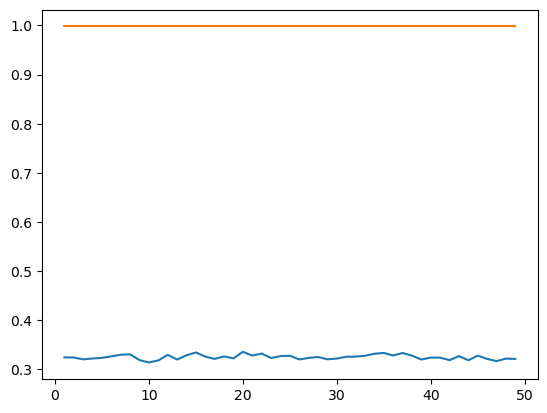

In [98]:
plt.plot(np.arange(1,50), resultat)
plt.plot(np.arange(1,50), train_score)

In [101]:
model = DecisionTreeRegressor(max_depth=9)
model.fit(X_train, y_train)
print(model.score(X_test, y_test))
print(math.sqrt(mean_squared_error(y_test, y_pred)))

0.6391824611724156
0.5775815828597071


In [106]:
features_importances = pd.DataFrame(data=model.feature_importances_, index=X_train.columns, columns=['importance']).sort_values(['importance'])

In [108]:
features_importances[features_importances['importance']<0.001]

,importance
Bed & Breakfast,0.000000
Boutique hotel,0.000000
Bungalow,0.000000
Hostel,0.000000
Timeshare,0.000000
...,...
Suitable for events,0.000819
Ethernet connection,0.000840
Shampoo,0.000917
cancellation_policy,0.000935


In [109]:
from sklearn.model_selection import validation_curve

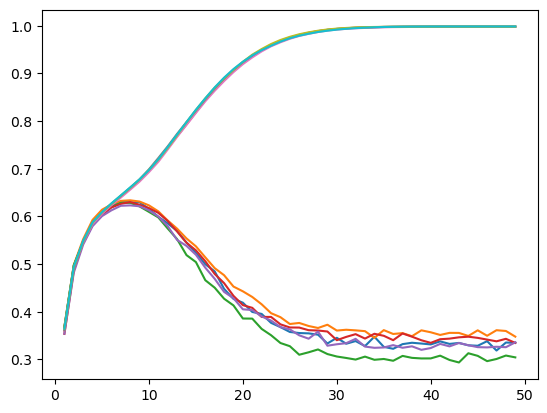

In [110]:
train_score, val_score = validation_curve(DecisionTreeRegressor( ), X_train, y_train,
                param_name='max_depth', param_range=np.arange(1,50), cv=5)
plt.plot(np.arange(1,50), val_score)
plt.plot(np.arange(1,50), train_score)